
# Titanic – Week 3 EDA + Similarity/Distance (scikit‑learn + matplotlib)

This notebook covers the **Week 3 EDA** tasks and extends with **row‑wise similarity/distance** analyses, using only `pandas`, `numpy`, `scikit‑learn`, and `matplotlib` (no seaborn). It includes:
- Data loading and light cleaning (minimal imputation for numeric columns)
- **Histograms** and **Boxplots** (overall + grouped by `Survived` if available)
- **Correlation heatmap** (Pearson, numeric features)
- **Cosine similarity** (rows, standardized numeric features)
- **Jaccard similarity** (rows, one‑hot categorical features)
- **Euclidean distance** (rows, standardized numeric features), plus optional **MDS** 2‑D projection

> **Input CSV path:** `Lab2_titanic.csv` (adjust in the first code cell if needed)



## 1) Imports & Config
Imports core libraries and sets the input path for the Titanic CSV.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import linkage, leaves_list

# --- Input path (adjust if necessary) ---
DATA_PATH = Path('Lab2_titanic.csv')

# Helper: safe figure saving
def savefig(fname, tight=True, dpi=200):
    if tight:
        plt.tight_layout()
    plt.savefig(fname, dpi=dpi)
    plt.show()



## 2) Load Data & Quick Inspection
Reads the Titanic dataset, prints shape, and previews the first few rows to verify schema.


In [2]:

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



## 3) Column Types & Minimal Imputation
Identifies numeric and categorical columns. Performs median imputation for numeric columns and most‑frequent imputation for categoricals to avoid dropping rows in plots/metrics.


In [3]:

# Detect numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Impute numeric
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_num = num_imputer.fit_transform(df[numeric_cols])
    df_num_imputed = pd.DataFrame(X_num, columns=numeric_cols, index=df.index)
else:
    df_num_imputed = pd.DataFrame(index=df.index)

# Impute categorical
if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_cat = cat_imputer.fit_transform(df[categorical_cols])
    df_cat_imputed = pd.DataFrame(X_cat, columns=categorical_cols, index=df.index)
else:
    df_cat_imputed = pd.DataFrame(index=df.index)

# Recombine in original column order (optional)
df_imputed = pd.concat([df_num_imputed, df_cat_imputed], axis=1)[df.columns]
df_imputed.head()


Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,B96 B98,S
1,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C
2,3.0,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,B96 B98,S
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S
4,5.0,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,B96 B98,S



## 4) Encoding & Scaling
Encodes categoricals via **Ordinal (label)** and **One‑Hot** encoders. Scales numeric features using **Min–Max** and **StandardScaler (Z‑score)** for comparability.


In [4]:

# --- Label encoding (for reference) ---
if len(categorical_cols):
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_ord = ord_enc.fit_transform(df_cat_imputed)
    ord_colnames = [c + '_label' for c in categorical_cols]
    df_label = pd.concat([df_num_imputed.reset_index(drop=True),
                          pd.DataFrame(X_cat_ord, columns=ord_colnames)], axis=1)
else:
    df_label = df_num_imputed.copy()

# --- One‑Hot encoding (for Jaccard + modeling) ---
if len(categorical_cols):
    oh_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    X_cat_oh = oh_enc.fit_transform(df_cat_imputed)
    oh_cols = oh_enc.get_feature_names_out(categorical_cols)
    df_onehot = pd.concat([df_num_imputed.reset_index(drop=True),
                           pd.DataFrame(X_cat_oh, columns=oh_cols, index=df.index)], axis=1)
else:
    df_onehot = df_num_imputed.copy()

# --- Scaling (numeric only) ---
mm = MinMaxScaler()
X_minmax = mm.fit_transform(df_num_imputed) if len(df_num_imputed.columns) else np.empty((len(df), 0))
df_minmax = pd.DataFrame(X_minmax, columns=df_num_imputed.columns, index=df.index)

ss = StandardScaler(with_mean=True, with_std=True)
X_z = ss.fit_transform(df_num_imputed) if len(df_num_imputed.columns) else np.empty((len(df), 0))
df_zscore = pd.DataFrame(X_z, columns=df_num_imputed.columns, index=df.index)

print("MinMax shape:", df_minmax.shape, "| Z-score shape:", df_zscore.shape)
df_zscore.head()


MinMax shape: (891, 7) | Z-score shape: (891, 7)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.730108,-0.789272,0.827377,-0.565736,0.432793,-0.473674,-0.502445
1,-1.726220,1.266990,-1.566107,0.663861,0.432793,-0.473674,0.786845
2,-1.722332,1.266990,0.827377,-0.258337,-0.474545,-0.473674,-0.488854
3,-1.718444,1.266990,-1.566107,0.433312,0.432793,-0.473674,0.420730
4,-1.714556,-0.789272,0.827377,0.433312,-0.474545,-0.473674,-0.486337



## 5) EDA – Histograms
Plots univariate histograms for key numeric variables (`Age`, `Fare`, `SibSp`, `Parch` if present). Adjust `bins` as needed.


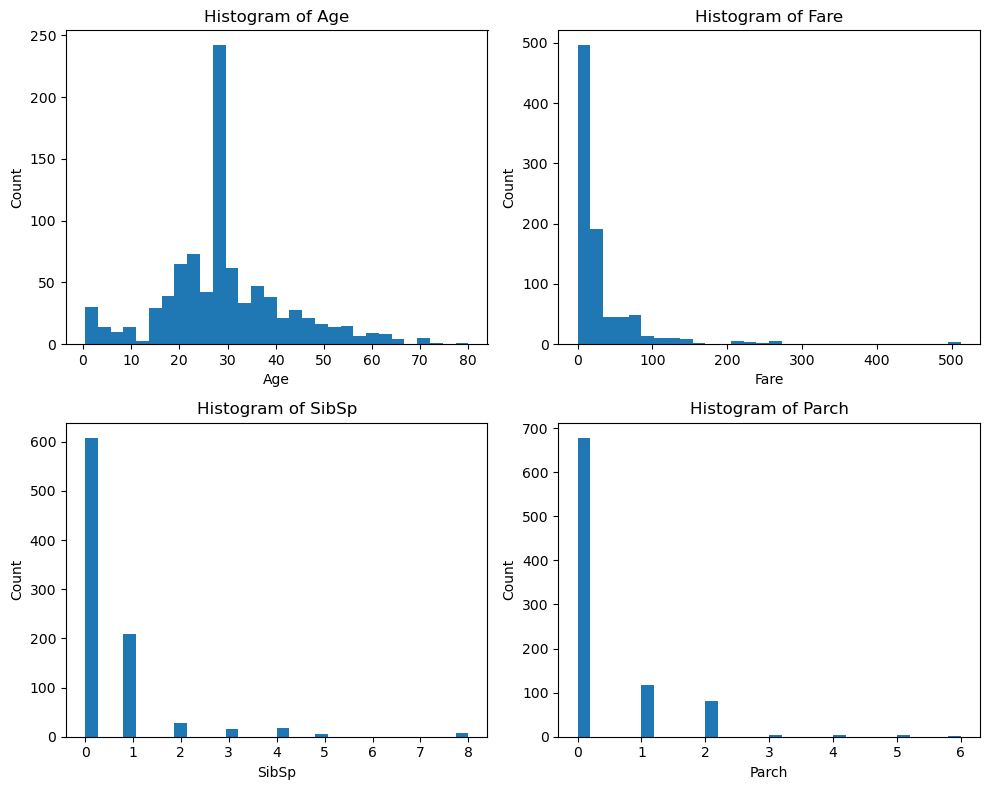

In [5]:

# Choose numeric variables for EDA
preferred = ['Age', 'Fare', 'SibSp', 'Parch']
num_cols_eda = [c for c in preferred if c in df_num_imputed.columns]
if not num_cols_eda:
    num_cols_eda = df_num_imputed.columns.tolist()[:4]  # fallback to first few numerics

n = len(num_cols_eda)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(10, 4*rows))
axes = np.array(axes).reshape(rows, 2)

for i, c in enumerate(num_cols_eda):
    r, k = divmod(i, 2)
    ax = axes[r, k]
    ax.hist(df_num_imputed[c].dropna(), bins=30)
    ax.set_title(f'Histogram of {c}')
    ax.set_xlabel(c)
    ax.set_ylabel('Count')

# Hide any leftover subplot
if n % 2 == 1:
    axes[-1, -1].axis('off')

savefig('eda_histograms.png')



## 6) EDA – Boxplots
Boxplots display central tendency, spread, and outliers. We plot overall boxplots and, if available, grouped by `Survived`.


/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/2835204267.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_num_imputed[c].dropna().values for c in num_cols_eda], labels=num_cols_eda, vert=True)


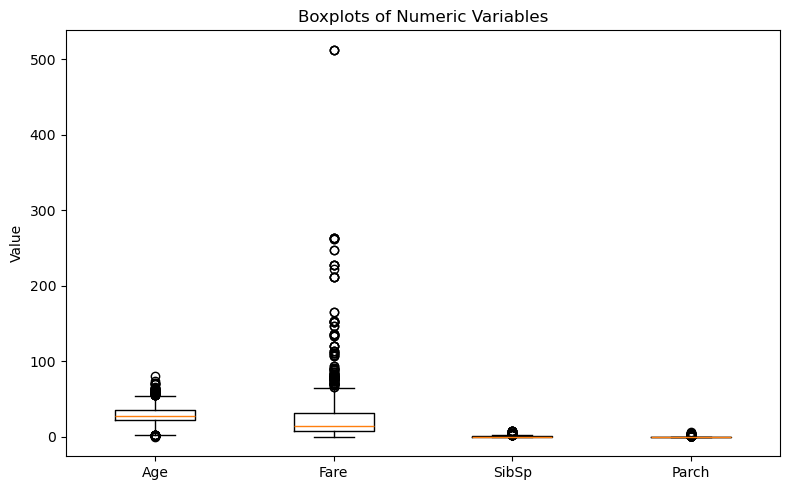

/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/2835204267.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/2835204267.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/2835204267.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/2835204267.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of box

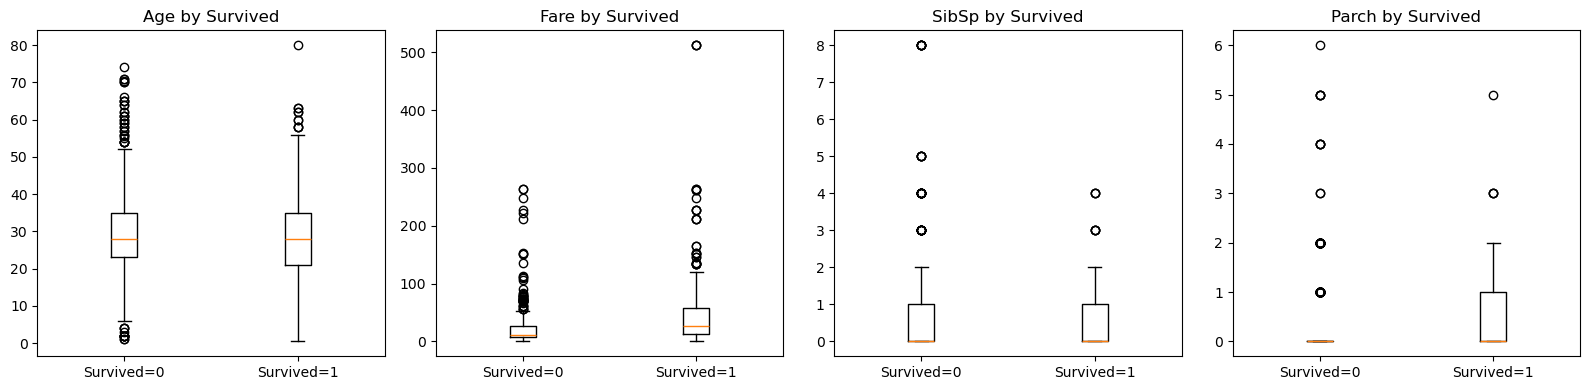

In [6]:

# Overall boxplots
plt.figure(figsize=(8, 5))
plt.boxplot([df_num_imputed[c].dropna().values for c in num_cols_eda], labels=num_cols_eda, vert=True)
plt.title('Boxplots of Numeric Variables')
plt.ylabel('Value')
savefig('eda_boxplots.png')

# Grouped by Survived (if present)
if 'Survived' in df.columns:
    fig, axes = plt.subplots(1, len(num_cols_eda), figsize=(4*len(num_cols_eda), 4))
    if len(num_cols_eda) == 1:
        axes = [axes]
    for ax, c in zip(axes, num_cols_eda):
        # guard for unique values
        uniq = pd.unique(df['Survived'].dropna())
        data = []
        labels = []
        for val in [0, 1]:
            if val in uniq:
                data.append(df_num_imputed.loc[df['Survived'] == val, c].dropna().values)
                labels.append(f'Survived={val}')
        if len(data) >= 1:
            ax.boxplot(data, labels=labels)
            ax.set_title(f'{c} by Survived')
    savefig('eda_boxplots_by_survived.png')



## 7) EDA – Correlation (Pearson) Heatmap
Computes Pearson correlations among numeric features and renders an annotated heatmap.


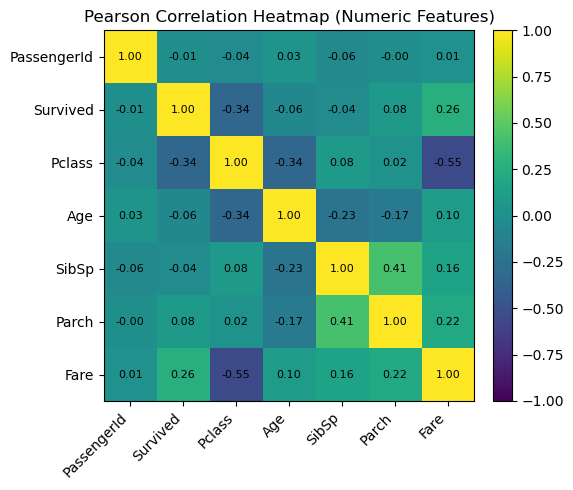

In [7]:

corr = df_num_imputed.corr(numeric_only=True, method='pearson')

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

# annotate cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title('Pearson Correlation Heatmap (Numeric Features)')
savefig('eda_corr_heatmap.png')



## 8) Row Subset for Similarity/Distance Matrices
To keep matrices compact for display, we limit to the first `subset` rows (adjustable).


In [8]:

subset = min(50, len(df_imputed))
idx = df_imputed.index[:subset]
print("Subset size for pairwise matrices:", subset)


Subset size for pairwise matrices: 50



## 9) Cosine Similarity (Standardized Numeric Features)
Computes cosine similarity on standardized numeric features, then shows a plain and clustered heatmap. Cosine emphasizes pattern orientation rather than magnitude.


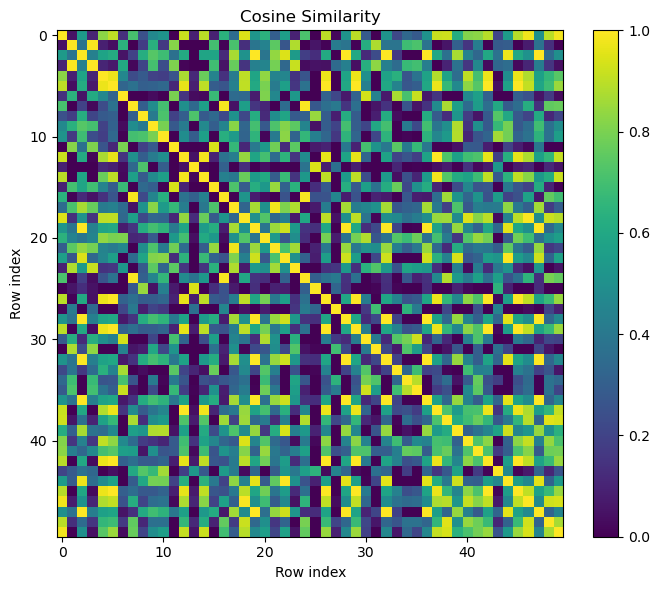

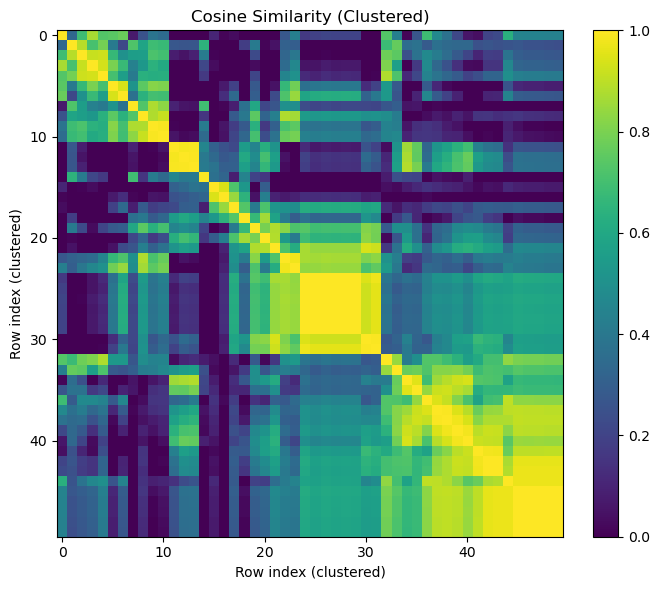

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.049,0.546,0.099,0.825,0.899,0.140,0.709,0.250,0.468
1,0.049,1.000,0.384,0.989,0.089,0.036,0.643,-0.029,0.180,0.636
2,0.546,0.384,1.000,0.434,0.579,0.614,0.053,0.198,0.623,0.735
3,0.099,0.989,0.434,1.000,0.103,0.067,0.606,0.022,0.209,0.704
4,0.825,0.089,0.579,0.103,1.000,0.971,0.461,0.233,0.284,0.197
5,0.899,0.036,0.614,0.067,0.971,1.000,0.326,0.371,0.303,0.313
6,0.140,0.643,0.053,0.606,0.461,0.326,1.000,-0.271,-0.064,0.029
7,0.709,-0.029,0.198,0.022,0.233,0.371,-0.271,1.000,0.300,0.488
8,0.250,0.180,0.623,0.209,0.284,0.303,-0.064,0.300,1.000,0.413
9,0.468,0.636,0.735,0.704,0.197,0.313,0.029,0.488,0.413,1.000


In [9]:

if df_zscore.shape[1] == 0:
    print("No numeric features available for cosine similarity.")
    cos_sim_df = pd.DataFrame()
else:
    X = df_zscore.iloc[:subset]
    cos_sim = cosine_similarity(X)
    cos_sim_df = pd.DataFrame(cos_sim, index=idx.astype(str), columns=idx.astype(str))

    # Plain heatmap
    plt.figure(figsize=(8, 6))
    im = plt.imshow(cos_sim_df, vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Cosine Similarity")
    plt.xlabel("Row index")
    plt.ylabel("Row index")
    savefig('cos-output.png')

    # Clustered heatmap
    dis = 1.0 - cos_sim
    Z = linkage(dis, method="average")
    order = leaves_list(Z)
    cos_ord = cos_sim_df.iloc[order, :].iloc[:, order]

    plt.figure(figsize=(8, 6))
    im2 = plt.imshow(cos_ord, vmin=0, vmax=1)
    plt.colorbar(im2, fraction=0.046, pad=0.04)
    plt.title("Cosine Similarity (Clustered)")
    plt.xlabel("Row index (clustered)")
    plt.ylabel("Row index (clustered)")
    savefig('cos-clustered.png')

cos_sim_df.iloc[:10, :10].round(3) if not cos_sim_df.empty else pd.DataFrame()



## 10) Jaccard Similarity (One‑Hot Categorical Features)
Uses the one‑hot portion of the feature matrix; Jaccard quantifies set overlap. We provide plain and clustered heatmaps.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


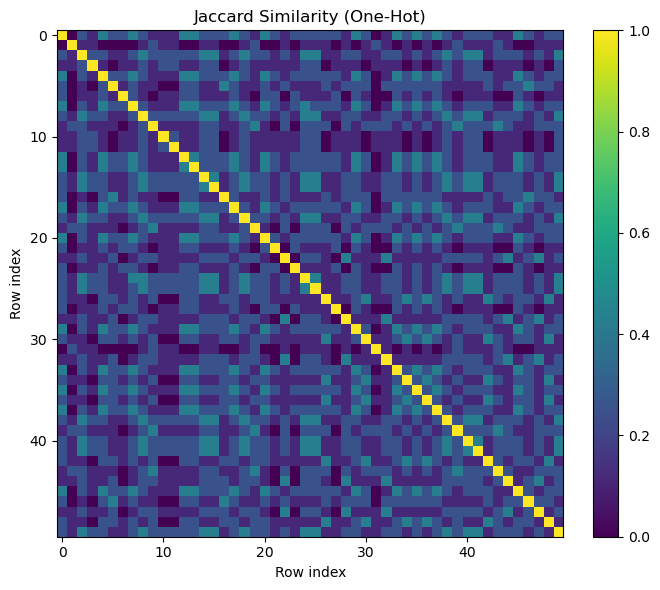

/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/4005203325.py:27: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dis, method="average")


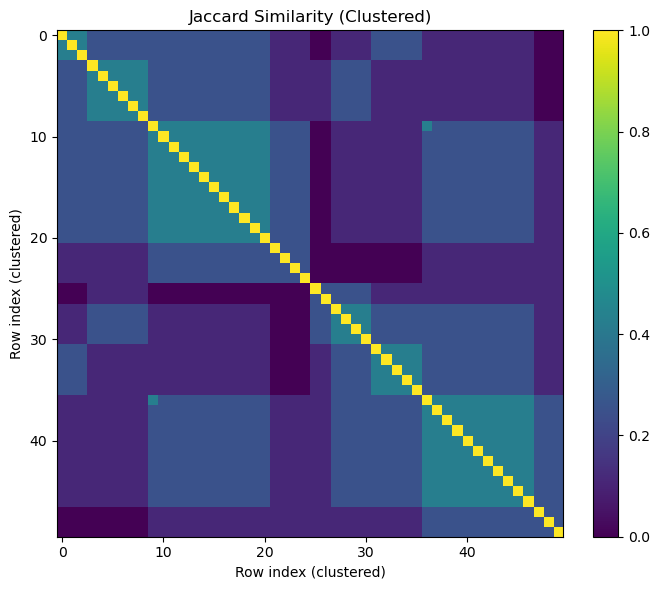

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.250,0.111,0.429,0.250,0.250,0.429,0.250,0.111
1,0.000,1.000,0.111,0.111,0.000,0.000,0.000,0.000,0.111,0.250
2,0.250,0.111,1.000,0.250,0.250,0.111,0.111,0.250,0.429,0.250
3,0.111,0.111,0.250,1.000,0.111,0.000,0.111,0.111,0.250,0.111
4,0.429,0.000,0.250,0.111,1.000,0.250,0.250,0.429,0.250,0.111
5,0.250,0.000,0.111,0.000,0.250,1.000,0.111,0.250,0.111,0.111
6,0.250,0.000,0.111,0.111,0.250,0.111,1.000,0.250,0.111,0.000
7,0.429,0.000,0.250,0.111,0.429,0.250,0.250,1.000,0.250,0.111
8,0.250,0.111,0.429,0.250,0.250,0.111,0.111,0.250,1.000,0.250
9,0.111,0.250,0.250,0.111,0.111,0.111,0.000,0.111,0.250,1.000


In [10]:

oh_only_cols = [c for c in df_onehot.columns if c not in numeric_cols]

if len(oh_only_cols) == 0:
    print("No one-hot categorical columns found. Skipping Jaccard.")
    jac_sim_df = pd.DataFrame()
else:
    X_bin = df_onehot.loc[idx, oh_only_cols].to_numpy(dtype=int)
    if X_bin.shape[1] == 0:
        print("One-hot matrix has zero columns for the selected subset. Skipping Jaccard.")
        jac_sim_df = pd.DataFrame()
    else:
        jac_dist = pairwise_distances(X_bin, metric='jaccard')
        jac_sim = 1.0 - jac_dist
        jac_sim_df = pd.DataFrame(jac_sim, index=idx.astype(str), columns=idx.astype(str))

        # Plain heatmap
        plt.figure(figsize=(8, 6))
        im = plt.imshow(jac_sim_df, vmin=0, vmax=1)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.title("Jaccard Similarity (One-Hot)")
        plt.xlabel("Row index")
        plt.ylabel("Row index")
        savefig('jac-output.png')

        # Clustered heatmap
        dis = 1.0 - jac_sim
        Z = linkage(dis, method="average")
        order = leaves_list(Z)
        jac_ord = jac_sim_df.iloc[order, :].iloc[:, order]

        plt.figure(figsize=(8, 6))
        im2 = plt.imshow(jac_ord, vmin=0, vmax=1)
        plt.colorbar(im2, fraction=0.046, pad=0.04)
        plt.title("Jaccard Similarity (Clustered)")
        plt.xlabel("Row index (clustered)")
        plt.ylabel("Row index (clustered)")
        savefig('jac-clustered.png')

jac_sim_df.iloc[:10, :10].round(3) if not jac_sim_df.empty else pd.DataFrame()



## 11) Euclidean Distance (Standardized Numeric Features) + MDS
Computes Euclidean distance on standardized numerics. Visualizes a plain and clustered heatmap, and an optional 2‑D **MDS** projection approximating pairwise distances.


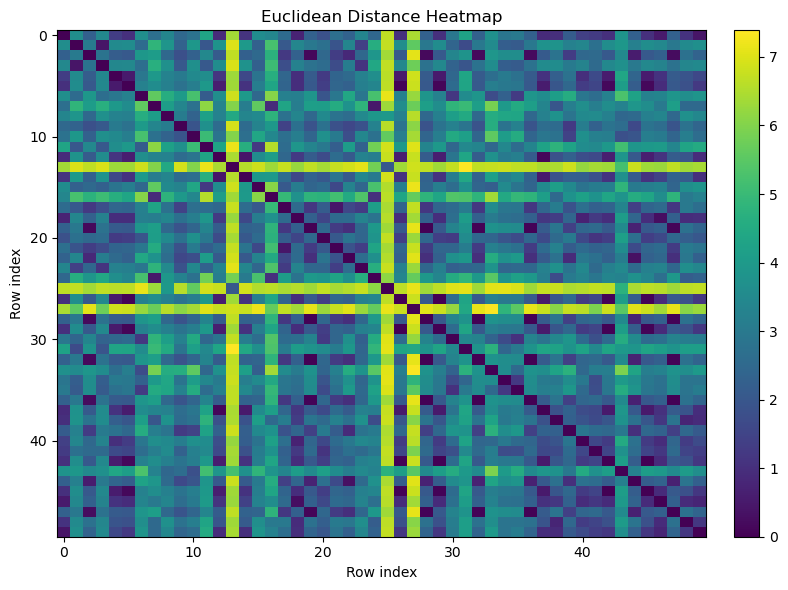

/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_28652/1034428121.py:19: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(euc, method="average")


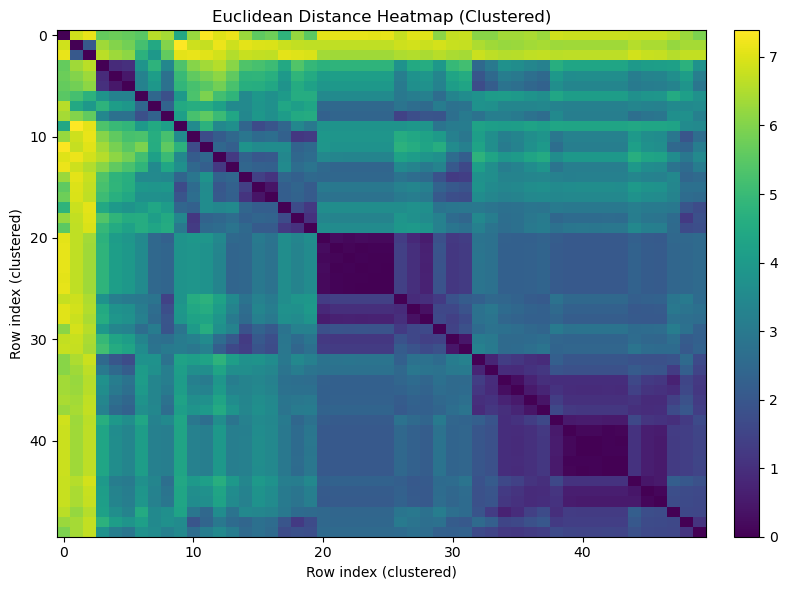

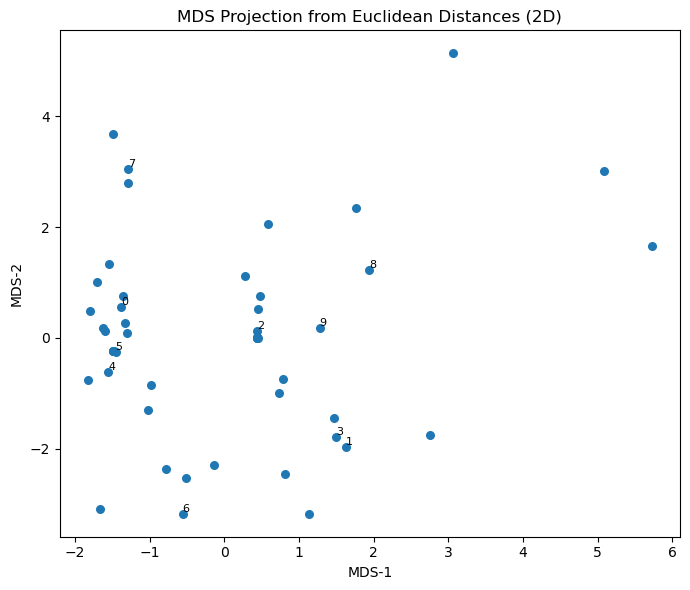

,0,1,2,3,4,5,6,7,8,9
0,0.000,3.624,2.269,3.436,1.350,1.018,3.662,2.697,3.372,2.500
1,3.624,0.000,3.005,0.433,3.529,3.602,2.592,4.844,3.860,2.350
2,2.269,3.005,0.000,2.803,2.169,2.062,3.920,4.081,2.485,1.818
3,3.436,0.433,2.803,0.000,3.406,3.446,2.680,4.652,3.716,2.062
4,1.350,3.529,2.169,3.406,0.000,0.538,2.939,3.931,3.282,3.047
5,1.018,3.602,2.062,3.446,0.538,0.000,3.238,3.607,3.225,2.798
6,3.662,2.592,3.920,2.680,2.939,3.238,0.000,5.571,4.593,4.016
7,2.697,4.844,4.081,4.652,3.931,3.607,5.571,0.000,4.112,3.373
8,3.372,3.860,2.485,3.716,3.282,3.225,4.593,4.112,0.000,3.092
9,2.500,2.350,1.818,2.062,3.047,2.798,4.016,3.373,3.092,0.000


In [11]:

if df_zscore.shape[1] == 0:
    print("No numeric features available for Euclidean distance. Skipping.")
    euc_df = pd.DataFrame()
else:
    X = df_zscore.iloc[:subset]
    euc = pairwise_distances(X, metric="euclidean")
    euc_df = pd.DataFrame(euc, index=idx.astype(str), columns=idx.astype(str))

    # Plain heatmap
    plt.figure(figsize=(8, 6))
    im = plt.imshow(euc_df, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Euclidean Distance Heatmap")
    plt.xlabel("Row index")
    plt.ylabel("Row index")
    savefig('output.png')  # keeps name aligned with your LaTeX

    # Clustered heatmap
    Z = linkage(euc, method="average")
    order = leaves_list(Z)
    euc_ord = euc_df.iloc[order, :].iloc[:, order]

    plt.figure(figsize=(8, 6))
    im2 = plt.imshow(euc_ord, aspect="auto")
    plt.colorbar(im2, fraction=0.046, pad=0.04)
    plt.title("Euclidean Distance Heatmap (Clustered)")
    plt.xlabel("Row index (clustered)")
    plt.ylabel("Row index (clustered)")
    savefig('euclid-clustered.png')

    # MDS 2-D projection
    try:
        mds = MDS(
            n_components=2,
            dissimilarity="precomputed",
            random_state=42,
            n_init=4,
            max_iter=600
        )
        coords = mds.fit_transform(euc)  # shape: (subset, 2)
        plt.figure(figsize=(7, 6))
        plt.scatter(coords[:, 0], coords[:, 1], s=30)
        # annotate a few points
        for k in range(min(10, len(idx))):
            plt.text(coords[k, 0], coords[k, 1], str(idx[k]), fontsize=8, ha="left", va="bottom")
        plt.title("MDS Projection from Euclidean Distances (2D)")
        plt.xlabel("MDS-1")
        plt.ylabel("MDS-2")
        savefig('euclid-mds.png')
    except Exception as ex:
        print(f"MDS skipped due to: {ex}")

euc_df.iloc[:10, :10].round(3) if not euc_df.empty else pd.DataFrame()



## 12) Summary
- **Histograms/Boxplots**: reveal distribution shape, spread, and outliers.
- **Correlation heatmap**: highlights linear relationships among numeric features.
- **Cosine similarity**: emphasizes orientation similarity in standardized numeric space.
- **Jaccard similarity**: measures set overlap across one‑hot categorical features.
- **Euclidean distance**: quantifies geometric separation; **MDS** offers an intuitive 2‑D map.
